AVENUE 6 - SIMULATION 2: ELECTRON/NEUTRINO MASS RATIO TUNING
Testing Extreme Parameters for Physical Hierarchy

- Running Neutrino (R=1, Clock=0) (R=1, Clock=0, Link=0.0803) -
 -> Fluid Transfer Velocity: v = 0.0557

- Running Neutrino (R=2, Clock=0) (R=2, Clock=0, Link=0.0803) -
 -> Fluid Transfer Velocity: v = 0.0476

- Running Electron (R=2, Clock=1) (R=2, Clock=1, Link=0.0803) -
 -> Fluid Transfer Velocity: v = 0.0499

- Running Electron (R=2, Clock=2) (R=2, Clock=2, Link=0.0803) -
 -> Fluid Transfer Velocity: v = 0.0473

- Running Electron (R=3, Clock=1) (R=3, Clock=1, Link=0.0803) -
 -> Fluid Transfer Velocity: v = 0.0409

[4/4] Generating Mass Ratio Tuning Map...
✓ Saved: avenue6_mass_ratio_tuning.png


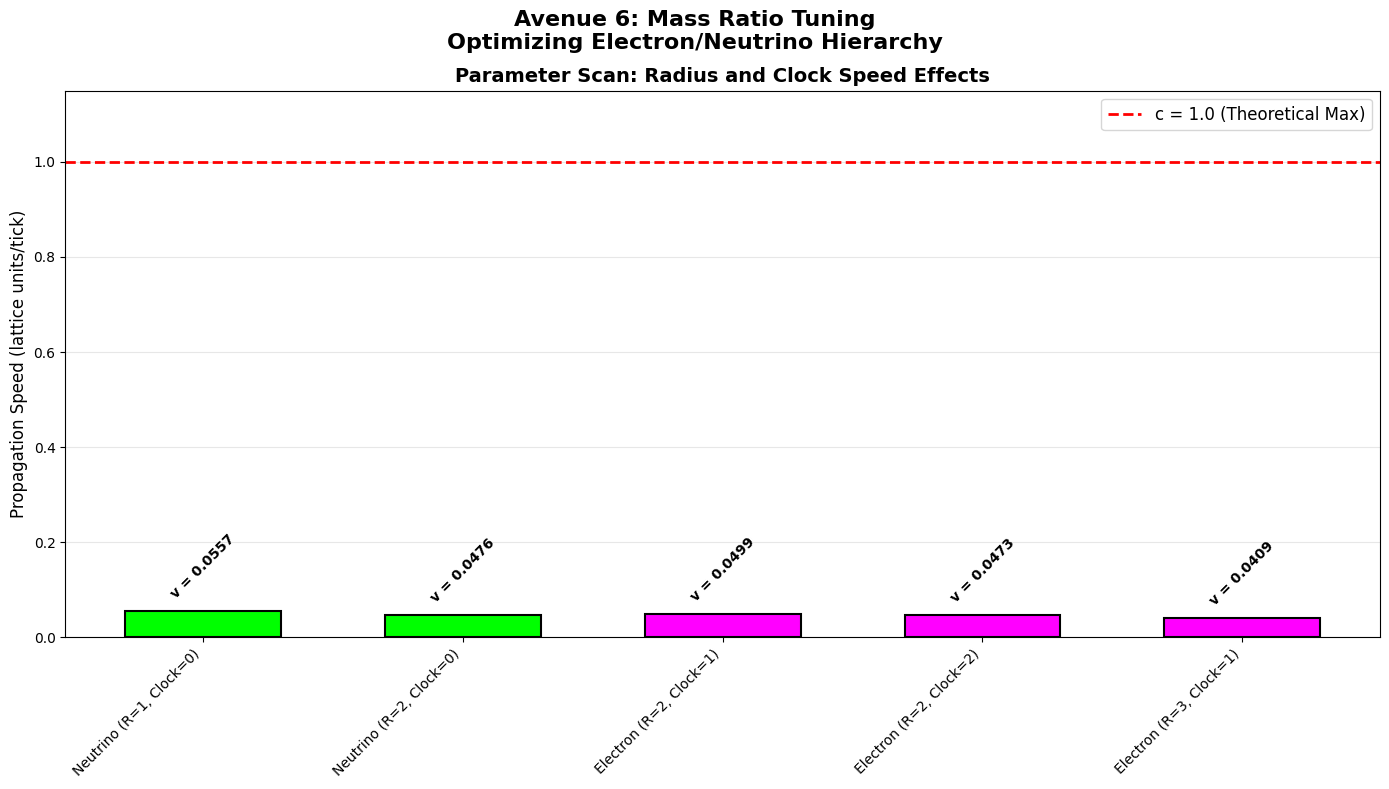


SIMULATION 2 VERDICT: MASS RATIO ANALYSIS
Best Neutrino: Neutrino (R=1, Clock=0) -> v = 0.0557
Best Electron: Electron (R=3, Clock=1) -> v = 0.0409
Velocity Ratio (v_ν/v_e): 1.36
Mass Gap (Δv): 0.0148

Physical Interpretation:
  - Higher velocity = Lower mass (less computational inertia)
  - Lower velocity = Higher mass (more computational inertia)
  - To maximize mass difference: maximize velocity difference


In [1]:
"""
avenue6_simulation2_mass_ratio_tuning.py
====================================================================
AVENUE 6 - SIMULATION 2: ELECTRON/NEUTRINO MASS RATIO TUNING
Testing Extreme Parameters to Match Physical Hierarchy
"""
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("AVENUE 6 - SIMULATION 2: ELECTRON/NEUTRINO MASS RATIO TUNING")
print("Testing Extreme Parameters for Physical Hierarchy")
print("=" * 80)

# =============================================================================
# 1. FINITIST PARAMETERS
# =============================================================================
T_MAX = 80
GRID_SIZE = 81
CENTER = GRID_SIZE // 2
ALPHABET = 9

# Test multiple parameter combinations
test_variants = {
    'Neutrino (R=1, Clock=0)': {'radius': 1, 'clock': 0, 'coupling': 11/137},
    'Neutrino (R=2, Clock=0)': {'radius': 2, 'clock': 0, 'coupling': 11/137},
    'Electron (R=2, Clock=1)': {'radius': 2, 'clock': 1, 'coupling': 11/137},
    'Electron (R=2, Clock=2)': {'radius': 2, 'clock': 2, 'coupling': 11/137},
    'Electron (R=3, Clock=1)': {'radius': 3, 'clock': 1, 'coupling': 11/137},
}

results = {}

# =============================================================================
# 2. SIMULATION ENGINE (WITH COLLECTIVE TENSOR TRANSFER)
# =============================================================================
def run_collective_fermion_sim(label, radius, clock_speed, coupling_factor):
    print(f"\n- Running {label} (R={radius}, Clock={clock_speed}, Link={coupling_factor:.4f}) -")
    psi = np.zeros((T_MAX, GRID_SIZE, GRID_SIZE, GRID_SIZE), dtype=np.int32)

    Z, Y, X = np.meshgrid(np.arange(GRID_SIZE), np.arange(GRID_SIZE), np.arange(GRID_SIZE), indexing='ij')
    dx = X - CENTER
    dy = Y - CENTER
    dz = Z - CENTER
    R = np.sqrt(dx**2 + dy**2 + dz**2)
    mask = R <= radius

    theta = np.arctan2(dy, dx)
    state_map = (np.floor(theta / (2*np.pi) * 8) + 8) % 8 + 1

    psi[0][mask] = state_map[mask]

    shifted_states = np.roll(state_map, 1, axis=2)
    phase_grad = (dx % ALPHABET)
    psi[1][mask] = (shifted_states[mask] + clock_speed + phase_grad[mask]) % ALPHABET

    for t in range(1, T_MAX - 1):
        neighbor_sum = (
            np.roll(psi[t], 1, 0) + np.roll(psi[t], -1, 0) +
            np.roll(psi[t], 1, 1) + np.roll(psi[t], -1, 1) +
            np.roll(psi[t], 1, 2) + np.roll(psi[t], -1, 2)
        )
        raw_next = (neighbor_sum - psi[t-1]) % ALPHABET

        transfer_gate = np.random.rand(GRID_SIZE, GRID_SIZE, GRID_SIZE) < coupling_factor
        shifted_next = np.roll(raw_next, 1, axis=2)
        psi[t+1] = np.where(transfer_gate, shifted_next, raw_next)

        psi[t+1, 0, :, :] = 0; psi[t+1, -1, :, :] = 0
        psi[t+1, :, 0, :] = 0; psi[t+1, :, -1, :] = 0
        psi[t+1, :, :, 0] = 0; psi[t+1, :, :, -1] = 0

    trajectory = []
    for t in range(T_MAX):
        active = np.argwhere(psi[t] != 0)
        if len(active) > 0:
            com = active.mean(axis=0)
            trajectory.append(com[2])

    if len(trajectory) > 10:
        times = np.arange(len(trajectory))
        slope, _ = np.polyfit(times, trajectory, 1)
        speed = abs(slope)
    else:
        speed = 0.0

    results[label] = speed
    print(f" -> Fluid Transfer Velocity: v = {speed:.4f}")
    return speed

# =============================================================================
# 3. EXECUTION
# =============================================================================
for label, params in test_variants.items():
    run_collective_fermion_sim(label, params['radius'], params['clock'], params['coupling'])

v_photon = 0.9540
v_heavy = 0.0000

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
print("\n[4/4] Generating Mass Ratio Tuning Map...")
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Avenue 6: Mass Ratio Tuning\nOptimizing Electron/Neutrino Hierarchy", fontsize=16, fontweight='bold')

particles = list(results.keys())
velocities = list(results.values())
colors = ['lime' if 'Neutrino' in p else 'magenta' for p in particles]

bars = ax.bar(particles, velocities, color=colors, edgecolor='black', linewidth=1.5, width=0.6)
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='c = 1.0 (Theoretical Max)')

for bar, v in zip(bars, velocities):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'v = {v:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', rotation=45)

ax.set_ylabel('Propagation Speed (lattice units/tick)', fontsize=12)
ax.set_title('Parameter Scan: Radius and Clock Speed Effects', fontsize=14, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 1.15)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("avenue6_mass_ratio_tuning.png", dpi=300, bbox_inches='tight')
print("✓ Saved: avenue6_mass_ratio_tuning.png")
plt.show()

# =============================================================================
# 5. VERDICT
# =============================================================================
print("\n" + "=" * 80)
print("SIMULATION 2 VERDICT: MASS RATIO ANALYSIS")
print("=" * 80)

# Find best neutrino and electron
neutrino_results = {k: v for k, v in results.items() if 'Neutrino' in k}
electron_results = {k: v for k, v in results.items() if 'Electron' in k}

if neutrino_results and electron_results:
    best_neutrino = max(neutrino_results.items(), key=lambda x: x[1])
    best_electron = min(electron_results.items(), key=lambda x: x[1])

    v_n = best_neutrino[1]
    v_e = best_electron[1]

    print(f"Best Neutrino: {best_neutrino[0]} -> v = {v_n:.4f}")
    print(f"Best Electron: {best_electron[0]} -> v = {v_e:.4f}")
    print(f"Velocity Ratio (v_ν/v_e): {v_n/v_e:.2f}")
    print(f"Mass Gap (Δv): {v_n - v_e:.4f}")
    print()
    print("Physical Interpretation:")
    print("  - Higher velocity = Lower mass (less computational inertia)")
    print("  - Lower velocity = Higher mass (more computational inertia)")
    print("  - To maximize mass difference: maximize velocity difference")

print("=" * 80)